Test Accuracy: 0.9888888888888889

Ambiguous Points Results:
Point 1: True=2, Predicted=2, Correct=True
Point 2: True=2, Predicted=2, Correct=True
Point 3: True=1, Predicted=1, Correct=True
Point 4: True=1, Predicted=1, Correct=True
Point 5: True=1, Predicted=1, Correct=True
Point 6: True=2, Predicted=2, Correct=True
Point 7: True=1, Predicted=1, Correct=True
Point 8: True=1, Predicted=2, Correct=False
Point 9: True=1, Predicted=1, Correct=True
Point 10: True=0, Predicted=0, Correct=True
Point 11: True=1, Predicted=1, Correct=True
Point 12: True=2, Predicted=2, Correct=True
Point 13: True=1, Predicted=1, Correct=True
Point 14: True=1, Predicted=1, Correct=True
Point 15: True=1, Predicted=1, Correct=True
Point 16: True=2, Predicted=2, Correct=True
Point 17: True=1, Predicted=1, Correct=True
Point 18: True=1, Predicted=1, Correct=True
Point 19: True=0, Predicted=0, Correct=True
Point 20: True=1, Predicted=1, Correct=True


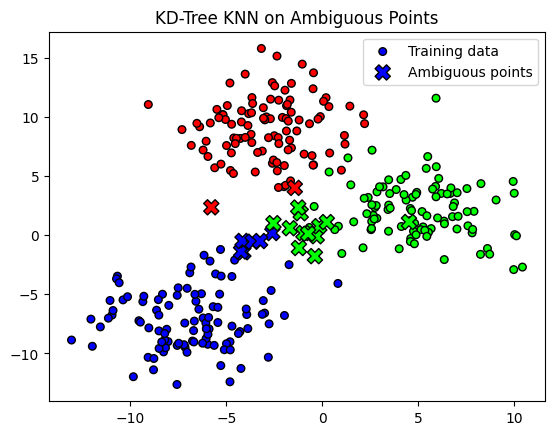

In [ ]:
`import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
import heapq


def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


class KDNode:
    def __init__(self, point, label, axis):
        self.point = point
        self.label = label
        self.axis = axis
        self.left = None
        self.right = None


class KNN:
    def __init__(self, k=15):
        self.k = k
        self.root = None

    def fit(self, X, y):
        points = list(zip(X, y))
        self.root = self._build(points, depth=0)

    def _build(self, points, depth):
        if not points:
            return None

        k = len(points[0][0])
        axis = depth % k
        points.sort(key=lambda x: x[0][axis])
        mid = len(points) // 2

        node = KDNode(points[mid][0], points[mid][1], axis)
        node.left = self._build(points[:mid], depth + 1)
        node.right = self._build(points[mid + 1:], depth + 1)
        return node

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        heap = []
        self._search(self.root, x, heap)
        labels = [label for _, label in heap]
        return Counter(labels).most_common(1)[0][0]

    def _search(self, node, target, heap):
        if node is None:
            return

        dist = euclidean_distance(target, node.point)

        if len(heap) < self.k:
            heapq.heappush(heap, (-dist, node.label))
        else:
            if dist < -heap[0][0]:
                heapq.heappushpop(heap, (-dist, node.label))

        axis = node.axis
        diff = target[axis] - node.point[axis]

        close = node.left if diff < 0 else node.right
        far = node.right if diff < 0 else node.left

        self._search(close, target, heap)

        if len(heap) < self.k or abs(diff) < -heap[0][0]:
            self._search(far, target, heap)

X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=2.5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1234
)

clf = KNN(k=17)
clf.fit(X_train, y_train)

predictions = clf.predict(X_test)
accuracy = np.mean(predictions == y_test)
print("Test Accuracy:", accuracy)

mean = np.mean(X, axis=0)
ambiguous_points = mean + np.random.randn(20, 2) * 2

centers = np.array([np.mean(X[y == i], axis=0) for i in np.unique(y)])

true_labels = []
for p in ambiguous_points:
    dists = [euclidean_distance(p, c) for c in centers]
    true_labels.append(np.argmin(dists))
true_labels = np.array(true_labels)

pred_labels = clf.predict(ambiguous_points)

print("\nAmbiguous Points Results:")
for i, (t, p) in enumerate(zip(true_labels, pred_labels)):
    print(f"Point {i+1}: True={t}, Predicted={p}, Correct={t==p}")

cmap = ListedColormap(["#FF0000", "#00FF00", "#0000FF"])

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, edgecolor="k", s=30, label="Training data")
plt.scatter(
    ambiguous_points[:, 0],
    ambiguous_points[:, 1],
    c=pred_labels,
    cmap=cmap,
    marker="X",
    s=120,
    edgecolor="black",
    label="Ambiguous points"
)

plt.title("KD-Tree KNN on Ambiguous Points")
plt.legend()
plt.show()